In [476]:
# %load_ext autoreload
# %autoreload 2

import pandas as pd
import re
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import os
from pathlib import Path
from pprint import pprint
from datetime import timedelta, datetime
import gnss_lib_py as glp
from gnss_lib_py.utils.ephemeris_downloader import load_ephemeris
from astropy.time import Time # datetime to TAI
from dataclasses import dataclass
from pymap3d import eci2ecef
from src.conversions import eci_to_ecef

plt.rcdefaults()

In [350]:
from src.lugre_parser import get_unique_timestamps, lugre_parser, get_unique_times, gps_seconds_to_gps_weeks
import pylupnt as pnt

## Importing Data

In [351]:
data_path = Path().joinpath("LuGRE Mission Data/L0/TLM/")
set_ids = get_unique_timestamps(data_path) # get all unique timestamps in the directory

# shrink set_ids to the ones on lunar surface
surface_ids = [set_id for set_id in set_ids if "_S_" in set_id]
print(len(surface_ids), "surface data sets found")


lugre_df = [lugre_parser(data_path, set_id) for set_id in surface_ids]

7 surface data sets found


/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Use

In [352]:
# print(lugre_df[0].keys())
print([lugre_df[0][i].columns for i in lugre_df[0].keys()])
# print(lugre_df[0]["info"])

[Index(['date', 'time', 'duration', 'phase', 'opnumber', 'index'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'signalId', 'svid', 'doppler',
       'codePhase', 'acfCorr', 'noiseFloor', 'acqMode', 'CN0'],
      dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'appName', 'wn', 'tow', 'decimals',
       'nSat', 'posX', 'posY', 'posZ', 'velX', 'velY', 'velZ', 'posStd',
       'velStd', 'timStd', 'clockBias', 'clockDrift', 'ggto', 'GDOP', 'PDOP',
       'HDOP', 'VDOP', 'TDOP'],
      dtype='object'), Index(['rxTime', 'signal', 'svId', 'Toe', 'Toc', 'iodNav', 'iodE', 'iodC'], dtype='object'), Index(['Receiver Time [s]', 'Clock Bias [m]', 'ClockDrift [m/s]'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'measures', 'svid', 'prRaw', 'cn0',
       'signalId', 'fdRaw', 'accDoppler', 'fdRateRaw'],
      dtype='object')]


## Coordinate and Time Transforms

In [353]:
dataset_id = 6

In [354]:
@dataclass
class TimeClass:
    gps_time_s: float
    tai_time: float
    utc_time: datetime

In [355]:
dataset = lugre_df[dataset_id]

rxTimes, (rxTime_start_s, src_min), (rxTime_end_s, src_max) = get_unique_times(dataset)

# print(f"Earliest GPS time: {rxTime_start_s}s from {src_min} in dataset:\n {dataset["info"]}\n")
# print(f"Latest GPS time: {rxTime_end_s}s from {src_max} in dataset:\n {dataset["info"]}\n")
print(f"Earliest GPS time [s]: {rxTime_start_s} from {src_min}")
print(f"Latest GPS time [s]: {rxTime_end_s} from {src_max}\n")
Dt = rxTime_end_s - rxTime_start_s
print(f"Delta_t [s]: {Dt}")

# Convert to UTC
gps_week_start, sec_into_week_start = gps_seconds_to_gps_weeks(rxTime_start_s)
gps_week_end, sec_into_week_end = gps_seconds_to_gps_weeks(rxTime_end_s)
print(f"GPS Week: {gps_week_start}, Start sec into week: {sec_into_week_start}, End sec into week: {sec_into_week_end}\n")

utc_start = glp.gps_millis_to_datetime(rxTime_start_s * 1000)
utc_end = glp.gps_millis_to_datetime(rxTime_end_s * 1000)
print(f"UTC Start time: \t{utc_start}\nUTC End time: \t\t{utc_end}\n")

# Convert to TAI
tai_start = pnt.gps2tai(rxTime_start_s)
tai_end = pnt.gps2tai(rxTime_end_s)
print(f"TAI Start time: \t{tai_start}\nTAI End time: \t\t{tai_end}")

start_time = TimeClass(rxTime_start_s, tai_start, utc_start)
end_time = TimeClass(rxTime_end_s, tai_end, utc_end)

tspan_tai = np.linspace(tai_start, tai_end, 200)

Earliest GPS time [s]: 1426198646.79952 from acq
Latest GPS time [s]: 1426200649.436493 from clk

Delta_t [s]: 2002.6369729042053
GPS Week: 2358, Start sec into week: 80246.79952001572, End sec into week: 82249.43649291992

UTC Start time: 	2025-03-16 22:17:08.799520+00:00
UTC End time: 		2025-03-16 22:50:31.436493+00:00

TAI Start time: 	1426198665.79952
TAI End time: 		1426200668.436493


In [395]:
# ECEF Position
rx_ecef = dataset['nav'][["posX", "posY", "posZ"]].to_numpy()
rxTime_nav = dataset['nav']["rxTime"]
rxTime_nav_tai: np.ndarray = np.zeros_like(rxTime_nav)
rxTime_nav_utc: list[datetime] = []
for i, t in enumerate(rxTime_nav):
    rxTime_nav_tai[i] = pnt.gps2tai(t)
    
    rxTime_nav_utc.append( glp.gps_millis_to_datetime(t * 1000) )

In [396]:
# Moon positions
moon_start_rv = pnt.get_body_pos_vel(rxTime_nav_tai, pnt.EARTH, pnt.MOON, pnt.MOON_CI)
moon_start_coe = pnt.cart2classical(moon_start_rv, pnt.GM_EARTH)

dyn_moon = pnt.KeplerianDynamics(pnt.GM_EARTH)
coe_moon_op = dyn_moon.propagate(moon_start_coe, start_time.tai_time, end_time.tai_time)

print(coe_moon_op)

moon_rv = pnt.classical2cart(coe_moon_op, pnt.GM_EARTH)

[[ 3.84807182e+05  5.39499132e-02  4.91364497e-01 -9.43732409e-02
   2.20775468e+00  2.77690203e+00]
 [ 3.84807193e+05  5.39498702e-02  4.91364497e-01 -9.43732397e-02
   2.20775419e+00  2.77690524e+00]
 [ 3.84807205e+05  5.39498271e-02  4.91364496e-01 -9.43732385e-02
   2.20775370e+00  2.77690846e+00]
 ...
 [ 3.84811725e+05  5.39324650e-02  4.91364426e-01 -9.43727621e-02
   2.20755587e+00  2.77820473e+00]
 [ 3.84811737e+05  5.39324219e-02  4.91364426e-01 -9.43727609e-02
   2.20755538e+00  2.77820795e+00]
 [ 3.84811748e+05  5.39323788e-02  4.91364425e-01 -9.43727597e-02
   2.20755488e+00  2.77821116e+00]]


In [487]:
# Normal moon for a day
sec_in_day = 24*3600.0
full_day = start_time.tai_time + np.linspace(0, sec_in_day, 1000)
full_day_utc = list(full_day - 37)

full_moon_start_rv = pnt.get_body_pos_vel(full_day, pnt.EARTH, pnt.MOON, pnt.MOON_CI)
full_moon_start_coe = pnt.cart2classical(full_moon_start_rv, pnt.GM_EARTH)
coe_moon_day = dyn_moon.propagate(full_moon_start_coe, start_time.tai_time, full_day[-1])

moon_orbit = pnt.classical2cart(coe_moon_day, pnt.GM_EARTH)
# print(coe_moon_year[0])
# print(full_moon)
print(start_time.utc_time)

2025-03-16 22:17:08.799520+00:00


In [488]:


new_moon = [eci_to_ecef(r[:3],t) for r, t in zip(moon_rv, rxTime_nav_utc)]
new_full_moon = [eci2ecef(*list(r[:3]),t) for r, t in zip(moon_orbit, rxTime_nav_utc)]
new_moon = np.array(new_moon)
new_full_moon = np.array(new_full_moon)
# new_full_moon = np.array(new_full_moon)
# np.apply_along_axis(eci2ecef)
print(new_full_moon)
print(new_moon)

[[-288753.21621423  230414.62690049 -166910.40720482]
 [-288793.92872525  230378.09813702 -166891.24507662]
 [-288834.63509762  230341.56596087 -166872.07533919]
 ...
 [-304134.97231296  216008.07281173 -158780.76990371]
 [-304173.21598077  215970.27551528 -158758.68203944]
 [-304211.45310422  215932.47502921 -158736.58694092]]
[[-228079.8685621   280178.59582564 -181565.25123368]
 [-228060.23189579  280194.69156902 -181565.11829981]
 [-228040.5940955   280210.785935   -181564.98536484]
 ...
 [-220035.10053334  286583.9844921  -181511.32183738]
 [-220015.01172377  286599.51657307 -181511.18845214]
 [-219994.92181557  286615.04724799 -181511.0550658 ]]


In [517]:
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, ITRS, CartesianRepresentation, get_body
import numpy as np

times_utc = [utc_start, utc_end]      # <--- replace with yours

# --- Convert to Astropy Time ---
t = Time(times_utc, scale='utc')

# --- Get Moon position in GCRS (in meters) ---
moon_gcrs = get_body('moon', t)    # returns GCRS

# --- Transform to Earth-fixed ITRS (ECEF) ---
moon_itrs = moon_gcrs.transform_to(ITRS(obstime=t))

# --- Extract ECEF XYZ in km ---
moon_ecef_km = np.column_stack([
    moon_itrs.x.to_value('km'),
    moon_itrs.y.to_value('km'),
    moon_itrs.z.to_value('km')
])

print(moon_ecef_km)   # plottable (N×3)

# # moon_rv: N x 6 (or N x >=3) array where columns 0..2 are position in *km* (as from pnt.classical2cart)
# # rxTime_nav_utc: list/array of corresponding Python datetimes in UTC

# # 1) Build astropy Time objects (UTC)
# times = Time(rxTime_nav_utc, scale='utc')

# # 2) Convert moon positions to meters and create a GCRS SkyCoord (inertial)
# moon_pos_m = moon_rv[:, :3] * 1000.0   # km -> m

# gcrs = SkyCoord(
#     x=moon_pos_m[:, 0],
#     y=moon_pos_m[:, 1],
#     z=moon_pos_m[:, 2],
#     representation_type=CartesianRepresentation,
#     unit='m',
#     frame=GCRS(obstime=times)
# )

# # 3) Transform to Earth-fixed (ITRS / ECEF)
# itrs = gcrs.transform_to(ITRS(obstime=times))

# # 4) Extract numpy array (meters)
# moon_ecef_m = np.vstack((itrs.x.value, itrs.y.value, itrs.z.value)).T    # shape (N,3), meters

# # If you prefer km:
# moon_ecef_km = moon_ecef_m / 1000.0

[[235086.9003712  319136.72782463 -85455.19592516]
 [277663.8217878  282637.55700308 -86297.68034209]]


## Plotting

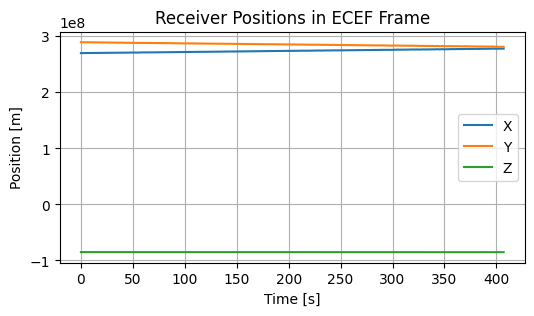

In [ ]:


# moon_pos = np.stack([moon_rv[:3]] * len(rxTime_nav_tai))

plt.figure(figsize=(6, 3))
plt.plot(rxTime_nav_tai - rxTime_nav_tai[0], rx_ecef[:,0], label='X')
plt.plot(rxTime_nav_tai - rxTime_nav_tai[0], rx_ecef[:,1], label='Y')
plt.plot(rxTime_nav_tai - rxTime_nav_tai[0], rx_ecef[:,2], label='Z')
# plt.plot(rxTime_nav_tai - rxTime_nav_tai[0], -moon_ecef_km[:,0], label='X')
# plt.plot(rxTime_nav_tai - rxTime_nav_tai[0], -moon_ecef_km[:,1], label='Y')
# plt.plot(rxTime_nav_tai - rxTime_nav_tai[0], -moon_ecef_km[:,2], label='Z')

plt.title("Receiver Positions in ECEF Frame")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
# plt.ylim(2e8, 4e8)
# plt.ylim(-5e8, 5e8)
plt.grid()
plt.legend()

In [459]:
# Orbital period analysis (to verify same frame)
def get_period(t, data):
    rad = (np.arctan2(data[0,1], data[0,0]) - np.arctan2(data[-1,1], data[-1,0]))
    rad_per_sec = rad / (t[-1] - t[0])
    period = 2 * np.pi/rad_per_sec
    return period
print(get_period(rxTime_nav_tai, rx_ecef) / (24*3600))
print(get_period(full_day_utc, moon_orbit) / (24*3600))
# (rxTime_nav_tai[-1] - rxTime_nav_tai[0])/(2 * piangle_rad) # seconds per radian

1.028284907045891
-29.376072835871305


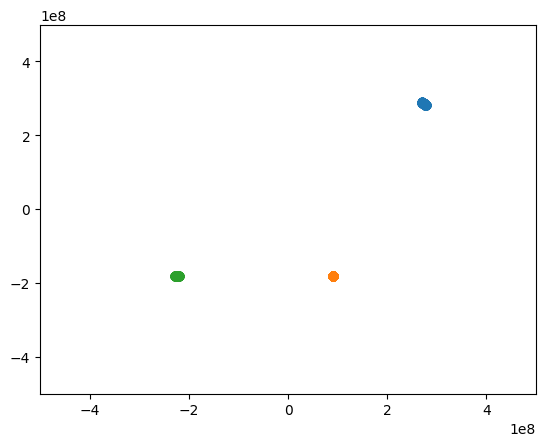

In [486]:
plt.scatter(rx_ecef[:,0], rx_ecef[:,1])
plt.xlim(-5e8, 5e8)
plt.ylim(-5e8, 5e8)
plt.scatter(moon_rv[:,0]*1000, moon_rv[:,2]*1000)
plt.scatter(new_moon[:,0]*1000, new_moon[:,2]*1000)
# plt.plot(moon_orbit[:,0]*1000, moon_orbit[:,1]*1000)
# plt.plot(new_full_moon[:,0]*1000, new_full_moon[:,1]*1000)


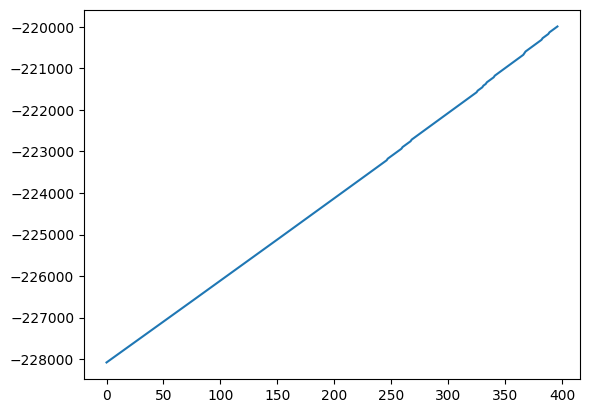

In [499]:
plt.plot(moon_ecef_km[:,0])

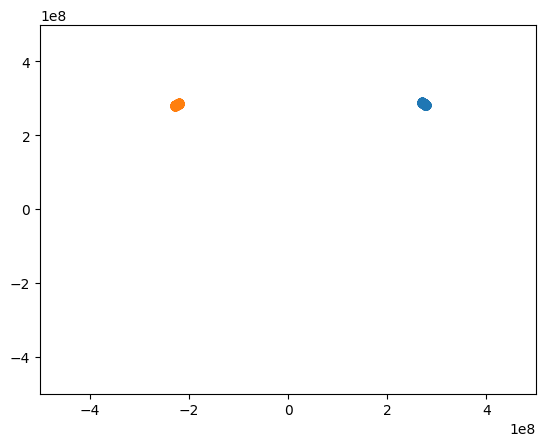

In [508]:
plt.scatter(rx_ecef[:,0], rx_ecef[:,1])
plt.xlim(-5e8, 5e8)
plt.ylim(-5e8, 5e8)
plt.scatter(moon_ecef_m[:,0], moon_ecef_m[:,1])
# plt.plot(moon_orbit[:,0]*1000, moon_orbit[:,1]*1000)
# plt.plot(new_full_moon[:,0]*1000, new_full_moon[:,1]*1000)
